# 模块三：回归问题与模型优化基础
**案例背景**：连续数值预测。本 Notebook 涵盖线性回归、梯度下降可视化、模型评估指标以及交叉验证和网格搜索调参。

# 线性模型（Linear Models）

本笔记本合并了该主题下的多个小实验，按小节依次编排。



---

## 线性回归



来源: 面经知识库 01-linear-models.md §1.4 线性回归


In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



## 1. 模拟数据生成


In [2]:
np.random.seed(42)
n_samples = 100
# 特征1: 房屋面积 (平方米)，范围 50-200
area = np.random.uniform(50, 200, n_samples)
# 特征2: 房龄 (年)，范围 1-30
age = np.random.uniform(1, 30, n_samples)

# 目标值: 房价 (万元)。假设真实关系: 价格 = 3 * 面积 - 1.5 * 房龄 + 50 + 噪声
noise = np.random.normal(0, 20, n_samples)  # 增加一些随机噪声
price = 3 * area - 1.5 * age + 50 + noise

# 组合特征矩阵 X
X = np.column_stack((area, age))
y = price



## 2. 模型训练


In [3]:
model = LinearRegression()
model.fit(X, y)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 3. 模型预测与评估


In [4]:
y_pred = model.predict(X)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("--- 线性回归模型结果 ---")
print(f"截距 (b): {model.intercept_:.2f}")
print(f"权重 (w1-面积, w2-房龄): {model.coef_[0]:.2f}, {model.coef_[1]:.2f}")
print(f"均方误差 (MSE): {mse:.2f}")
print(f"R平方值 (R2): {r2:.2f}")



--- 线性回归模型结果 ---
截距 (b): 49.99
权重 (w1-面积, w2-房龄): 2.95, -1.00
均方误差 (MSE): 378.27
R平方值 (R2): 0.98


## 4. 可视化 (仅展示面积与价格的关系)


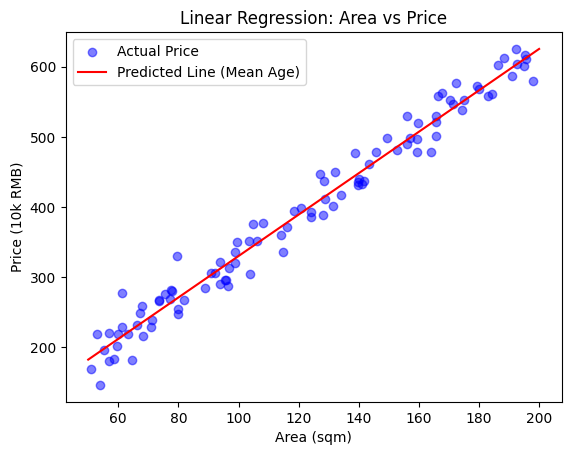

In [5]:
plt.scatter(area, y, color="blue", label="Actual Price", alpha=0.5)
# 固定房龄为平均值来画预测线
mean_age = np.mean(age)
area_line = np.linspace(50, 200, 100)
price_line = model.intercept_ + model.coef_[0] * area_line + model.coef_[1] * mean_age
plt.plot(area_line, price_line, color="red", label="Predicted Line (Mean Age)")
plt.xlabel("Area (sqm)")
plt.ylabel("Price (10k RMB)")
plt.title("Linear Regression: Area vs Price")
plt.legend()
if "agg" in mpl.get_backend().lower():
    plt.close("all")
else:
    plt.show()


# 梯度下降原理与通俗实例 (Gradient Descent)

## 1. 核心思想：蒙眼下山

想象你被蒙住双眼，放在了一座高山上，你的目标是**走到谷底**（寻找损失函数的最小值）。
因为你看不见，你只能用脚去感受周围的坡度：
1. 你用脚探一探，找到**最陡峭的下坡方向**（计算梯度）。
2. 朝着这个方向**迈出一步**（步长，即学习率）。
3. 在新的位置重复上述过程。
4. 直到你发现无论往哪个方向走，都是上坡或者平地，说明你已经到了谷底（达到局部/全局最优解）。

这就是**梯度下降（Gradient Descent）**的直观原理。

---

## 2. 数学原理解析

在机器学习中，我们希望模型预测的误差尽可能小。这个误差用**损失函数（Loss Function）** $J(\theta)$ 来表示，其中 $\theta$ 是模型的参数（比如权重 $w$ 和偏置 $b$）。

梯度下降的更新公式非常简单：
$$ \theta_{new} = \theta_{old} - \alpha \cdot \nabla J(\theta_{old}) $$

*   **$\theta$**：当前所在的位置（模型参数）。
*   **$\nabla J(\theta)$**：梯度（导数）。在数学上，梯度指向函数值**增加最快**的方向。因为我们要下山（减小误差），所以要加上**负号**，即向梯度的反方向走。
*   **$\alpha$ (Alpha)**：学习率（Learning Rate），也就是你每次迈出的**步子大小**。
    *   步子太大（$\alpha$ 太大）：容易直接跨过谷底，甚至跑到对面的山坡上，导致“震荡”甚至“发散”。
    *   步子太小（$\alpha$ 太小）：下山速度极慢，需要走非常多步才能到谷底。

---

## 3. 极简实例：寻找 $f(x) = x^2$ 的最小值

假设我们的损失函数是一个简单的抛物线：$f(x) = x^2$
我们知道它的最小值在 $x = 0$ 处。现在我们用梯度下降让计算机自己找到它。

1. **求导数（梯度）**：$f'(x) = 2x$
2. **设定初始位置**：假设我们随机降落在 $x = 5$ 的位置。
3. **设定学习率**：$\alpha = 0.1$

**开始下山（迭代）：**

*   **第 1 步**：
    *   当前位置 $x = 5$
    *   计算梯度：$2 \times 5 = 10$
    *   更新位置：$x_{new} = 5 - 0.1 \times 10 = 5 - 1 = 4$
    *   现在我们来到了 $x = 4$，离谷底更近了！

*   **第 2 步**：
    *   当前位置 $x = 4$
    *   计算梯度：$2 \times 4 = 8$
    *   更新位置：$x_{new} = 4 - 0.1 \times 8 = 4 - 0.8 = 3.2$

*   **第 3 步**：
    *   当前位置 $x = 3.2$
    *   计算梯度：$2 \times 3.2 = 6.4$
    *   更新位置：$x_{new} = 3.2 - 0.1 \times 6.4 = 2.56$

你会发现，随着 $x$ 越来越接近谷底 $0$，梯度（坡度）也越来越小，每次迈出的实际物理距离（$\alpha \times \text{梯度}$）也会自动变小，最终稳稳地停在 $x \approx 0$ 处。

---

## 4. Python 代码演示

下面是一段简单的 Python 代码，演示了上述 $f(x) = x^2$ 的梯度下降过程。你可以直接运行它来观察参数是如何一步步逼近最优解的。

初始位置: x = 5.0000, 损失 = 25.0000
第  1 步: x = 4.0000, 梯度 = 10.0000, 损失 = 16.0000
第  2 步: x = 3.2000, 梯度 = 8.0000, 损失 = 10.2400
第  3 步: x = 2.5600, 梯度 = 6.4000, 损失 = 6.5536
第  4 步: x = 2.0480, 梯度 = 5.1200, 损失 = 4.1943
第  5 步: x = 1.6384, 梯度 = 4.0960, 损失 = 2.6844
第  6 步: x = 1.3107, 梯度 = 3.2768, 损失 = 1.7180
第  7 步: x = 1.0486, 梯度 = 2.6214, 损失 = 1.0995
第  8 步: x = 0.8389, 梯度 = 2.0972, 损失 = 0.7037
第  9 步: x = 0.6711, 梯度 = 1.6777, 损失 = 0.4504
第 10 步: x = 0.5369, 梯度 = 1.3422, 损失 = 0.2882
第 11 步: x = 0.4295, 梯度 = 1.0737, 损失 = 0.1845
第 12 步: x = 0.3436, 梯度 = 0.8590, 损失 = 0.1181
第 13 步: x = 0.2749, 梯度 = 0.6872, 损失 = 0.0756
第 14 步: x = 0.2199, 梯度 = 0.5498, 损失 = 0.0484
第 15 步: x = 0.1759, 梯度 = 0.4398, 损失 = 0.0309
第 16 步: x = 0.1407, 梯度 = 0.3518, 损失 = 0.0198
第 17 步: x = 0.1126, 梯度 = 0.2815, 损失 = 0.0127
第 18 步: x = 0.0901, 梯度 = 0.2252, 损失 = 0.0081
第 19 步: x = 0.0721, 梯度 = 0.1801, 损失 = 0.0052
第 20 步: x = 0.0576, 梯度 = 0.1441, 损失 = 0.0033


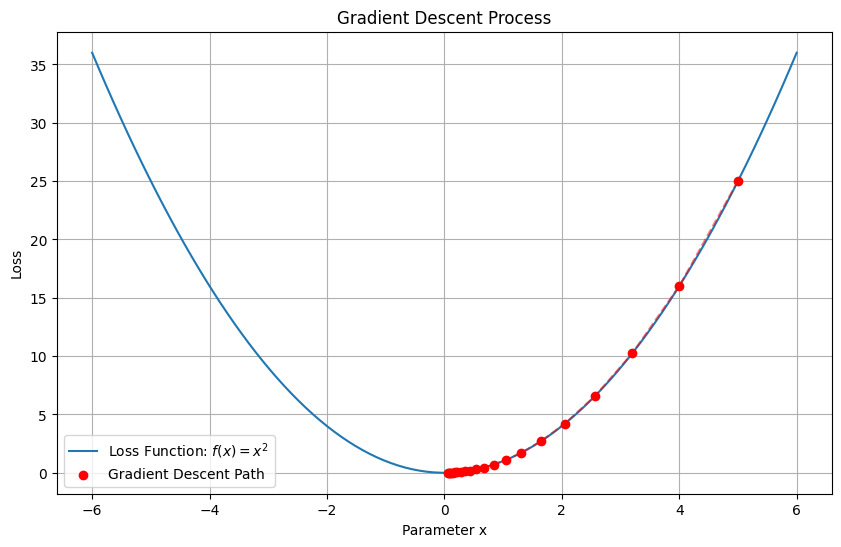

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 定义损失函数和它的梯度（导数）
def loss_function(x):
    return x ** 2

def gradient(x):
    return 2 * x

# 2. 初始化参数
x_current = 5.0      # 初始位置（随机猜一个参数）
learning_rate = 0.1  # 学习率（步长）
epochs = 20          # 迭代次数（走多少步）

# 用于记录轨迹，方便画图
x_history = [x_current]
loss_history = [loss_function(x_current)]

print(f"初始位置: x = {x_current:.4f}, 损失 = {loss_function(x_current):.4f}")

# 3. 开始梯度下降迭代
for i in range(epochs):
    # 计算当前位置的梯度
    grad = gradient(x_current)
    
    # 更新参数：向梯度的反方向移动
    x_current = x_current - learning_rate * grad
    
    # 记录轨迹
    x_history.append(x_current)
    loss_history.append(loss_function(x_current))
    
    print(f"第 {i+1:2d} 步: x = {x_current:.4f}, 梯度 = {grad:.4f}, 损失 = {loss_function(x_current):.4f}")

# 4. 可视化下山过程
x_vals = np.linspace(-6, 6, 100)
y_vals = loss_function(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='Loss Function: $f(x) = x^2$')
plt.scatter(x_history, loss_history, color='red', zorder=5, label='Gradient Descent Path')
plt.plot(x_history, loss_history, color='red', linestyle='dashed', alpha=0.5)

plt.title('Gradient Descent Process')
plt.xlabel('Parameter x')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 5. 机器学习中的实际应用（线性回归）

在真实的机器学习（如线性回归预测房价）中，原理完全一样，只是维度变高了：
*   **位置 $x$** 变成了模型的权重矩阵 $W$ 和偏置 $b$。
*   **损失函数** 变成了均方误差（MSE）：$J(W, b) = \frac{1}{N} \sum (y_{pred} - y_{true})^2$
*   **梯度** 变成了损失函数对每个权重 $w_i$ 和 $b$ 的偏导数。

计算机通过不断计算所有数据的误差梯度，微调 $W$ 和 $b$，最终拟合出一条最能代表数据规律的直线。

---

## 6. 进阶：Adam 优化器 (Adaptive Moment Estimation)

基础的梯度下降（Vanilla Gradient Descent）虽然简单，但在复杂地形中会遇到问题：
1. **平缓区域走得太慢**：如果坡度很小（梯度接近 0），它每次只能迈出极小的一步，半天走不到谷底。
2. **峡谷地形来回震荡**：如果地形像个狭长的山谷，它会在山谷两壁之间来回“撞墙”（震荡），很难沿着谷底快速前进。

为了解决这些问题，大神们发明了 **Adam 优化器**，它是目前深度学习中最常用的默认优化器。你可以把它理解为给下山的人穿上了一双**带有智能导航和惯性系统的滑板鞋**。

Adam 结合了两个核心思想：
1. **动量 (Momentum) - “惯性系统”**：
   就像推着一个重石头下山，它会积累之前的速度。即使当前遇到了一点平地或小坑，它也能靠着之前的惯性冲过去。这解决了平缓区域走得太慢的问题。
2. **自适应学习率 (RMSProp) - “智能刹车系统”**：
   它会记录每个方向的陡峭程度。如果某个方向一直很陡（梯度大），它会**调小**这个方向的步长，防止震荡（刹车）；如果某个方向一直很平缓（梯度小），它会**调大**步长，加速前进（踩油门）。

### 代码对比：标准梯度下降 vs Adam

下面我们构造一个“峡谷”地形：$f(x, y) = x^2 + 10y^2$。在 $y$ 方向非常陡峭，在 $x$ 方向非常平缓。
我们来看看标准梯度下降和 Adam 在这种地形下的表现差异。

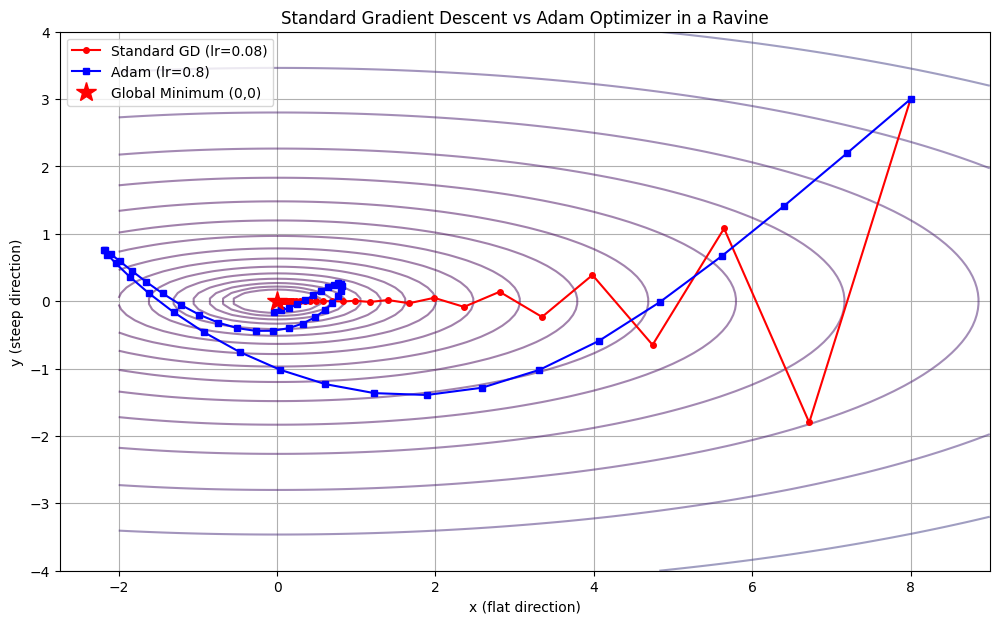

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 定义峡谷地形的损失函数和梯度
def loss_2d(x, y):
    return x**2 + 10 * y**2

def grad_2d(x, y):
    return np.array([2*x, 20*y])

# 2. 标准梯度下降 (Vanilla GD)
def vanilla_gd(start_pos, lr, epochs):
    pos = np.array(start_pos, dtype=float)
    path = [pos.copy()]
    for _ in range(epochs):
        g = grad_2d(pos[0], pos[1])
        pos -= lr * g
        path.append(pos.copy())
    return np.array(path)

# 3. Adam 优化器
def adam(start_pos, lr, epochs, beta1=0.9, beta2=0.999, epsilon=1e-8):
    pos = np.array(start_pos, dtype=float)
    path = [pos.copy()]
    m = np.zeros(2) # 一阶矩（动量）
    v = np.zeros(2) # 二阶矩（自适应学习率）
    
    for t in range(1, epochs + 1):
        g = grad_2d(pos[0], pos[1])
        
        # 更新动量
        m = beta1 * m + (1 - beta1) * g
        # 更新二阶矩
        v = beta2 * v + (1 - beta2) * (g**2)
        
        # 偏差修正（针对初期迭代）
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        
        # 更新位置
        pos -= lr * m_hat / (np.sqrt(v_hat) + epsilon)
        path.append(pos.copy())
        
    return np.array(path)

# 4. 运行对比
start_position = [8.0, 3.0] # 初始位置在峡谷的高处
epochs = 50

# 注意：Adam 的学习率通常比标准 GD 大一些
path_gd = vanilla_gd(start_position, lr=0.08, epochs=epochs)
path_adam = adam(start_position, lr=0.8, epochs=epochs)

# 5. 画图可视化
x = np.linspace(-2, 9, 100)
y = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x, y)
Z = loss_2d(X, Y)

plt.figure(figsize=(12, 7))
plt.contour(X, Y, Z, levels=np.logspace(-0.5, 3, 20), cmap='viridis', alpha=0.5)

# 画出两条轨迹
plt.plot(path_gd[:, 0], path_gd[:, 1], 'o-', color='red', label='Standard GD (lr=0.08)', markersize=4)
plt.plot(path_adam[:, 0], path_adam[:, 1], 's-', color='blue', label='Adam (lr=0.8)', markersize=4)

plt.plot(0, 0, 'r*', markersize=15, label='Global Minimum (0,0)') # 谷底位置

plt.title('Standard Gradient Descent vs Adam Optimizer in a Ravine')
plt.xlabel('x (flat direction)')
plt.ylabel('y (steep direction)')
plt.legend()
plt.grid(True)
plt.show()


### 观察结果：

运行上面的代码，你会看到一张等高线图（代表峡谷地形）：

1. **红色轨迹（标准梯度下降）**：
   在 $y$ 方向（陡峭方向）来回震荡，而在 $x$ 方向（平缓方向）前进得非常缓慢。如果把学习率调大，它甚至会直接飞出峡谷。
2. **蓝色轨迹（Adam）**：
   它几乎没有震荡！Adam 聪明地发现 $y$ 方向太陡了，于是自动“踩刹车”减小了 $y$ 方向的步伐；同时发现 $x$ 方向太平缓了，于是“踩油门”加大了 $x$ 方向的步伐。最终它平滑且快速地滑向了谷底 $(0,0)$。

这就是为什么在训练复杂的神经网络时，大家几乎都会首选 **Adam** 优化器。

# 模型评估与调参（Evaluation & Tuning）

本笔记本合并了该主题下的多个小实验，按小节依次编排。



---

## 交叉验证



来源: 面经知识库 06-model-evaluation-tuning.md §1.2


In [8]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

model = RandomForestClassifier(random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=kf, scoring="accuracy")

print("--- K折交叉验证结果 ---")
print(f"每一次的准确率: {scores}")
print(f"平均准确率: {np.mean(scores):.4f}")
print(f"准确率标准差: {np.std(scores):.4f}")


--- K折交叉验证结果 ---
每一次的准确率: [0.895 0.86  0.935 0.88  0.925]
平均准确率: 0.8990
准确率标准差: 0.0278


---

## 网格搜索



来源: 面经知识库 06-model-evaluation-tuning.md §2.2


In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=500, n_features=10, random_state=42)

model = RandomForestClassifier(random_state=42)
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring="accuracy", n_jobs=-1)

print("开始网格搜索，请稍候...")
grid_search.fit(X, y)

print("--- 网格搜索结果 ---")
print(f"最佳超参数组合: {grid_search.best_params_}")
print(f"最佳交叉验证得分: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_


开始网格搜索，请稍候...
--- 网格搜索结果 ---
最佳超参数组合: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
最佳交叉验证得分: 0.9380


---

## ROC/AUC 与类别不平衡



来源: 面经知识库 06-model-evaluation-tuning.md §3.2


--- 类别不平衡下的分类报告 ---
              precision    recall  f1-score   support

           0       0.97      0.88      0.92       262
           1       0.50      0.84      0.63        38

    accuracy                           0.87       300
   macro avg       0.74      0.86      0.78       300
weighted avg       0.91      0.87      0.89       300



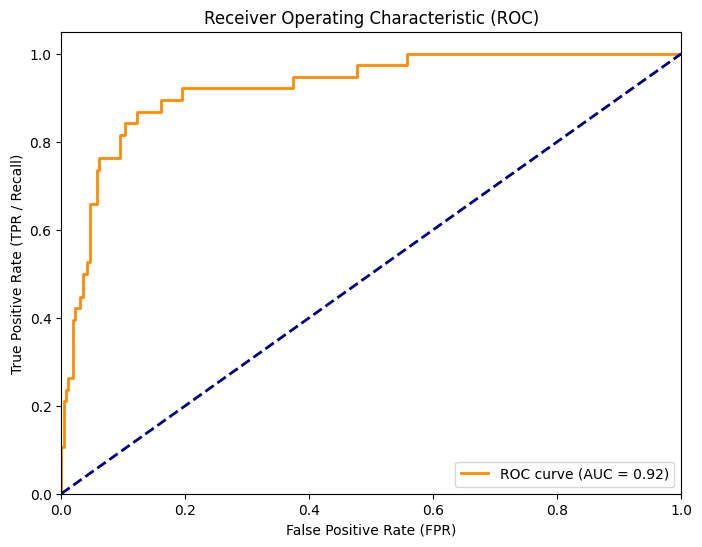

In [10]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, classification_report

X, y = make_classification(n_samples=1000, n_features=10, weights=[0.9, 0.1], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression(class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("--- 类别不平衡下的分类报告 ---")
print(classification_report(y_test, y_pred))

fpr, tpr, _thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR / Recall)")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
if "agg" in mpl.get_backend().lower():
    plt.close("all")
else:
    plt.show()
